In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import pearsonr  

In [2]:
# Генерация случайных значений для осей X и Y
np.random.seed(42)
n = 300  # количество точек
x = np.random.uniform(10000, 100000, n)  # значения от 10.000 до 100.000 рублей

# Добавляем больше шума и выбросы
y = np.random.normal(loc=0.03 * x / 100000 + 0.005, scale=0.003, size=n)  # увеличили шум
y += np.random.rand(n) * 0.02  # добавили дополнительный шум

# Добавляем несколько сильных выбросов
outliers_idx = np.random.choice(np.arange(n), size=int(n*0.05), replace=False)  # выбираем 5% точек как выбросы
y[outliers_idx] *= 3  # делаем выбросы в три раза больше среднего

# Фильтрация слишком высоких выбросов (значений больше 6%)
y[y > 0.06] = 0.06


In [3]:
# Создание полиномиального преобразования для регрессии
poly_reg = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

# Подгонка модели
poly_reg.fit(x.reshape(-1, 1), y)

# Вычисление тренда
trend_x = np.linspace(x.min(), x.max(), 50).reshape(-1, 1)
trend_y = poly_reg.predict(trend_x)

# Расчет коэффициента детерминации R²
r_squared = r2_score(y, poly_reg.predict(x.reshape(-1, 1)))

# Расчет коэффициента корреляции Пирсона
corr_coef, _ = pearsonr(x, y)

# Определение точек выше и ниже трендовой линии
above_trend = y > poly_reg.predict(x.reshape(-1, 1))
below_trend = ~above_trend

# Индексы для нормальных точек (не выбросов)
normal_points_idx = ~np.isin(np.arange(n), outliers_idx)


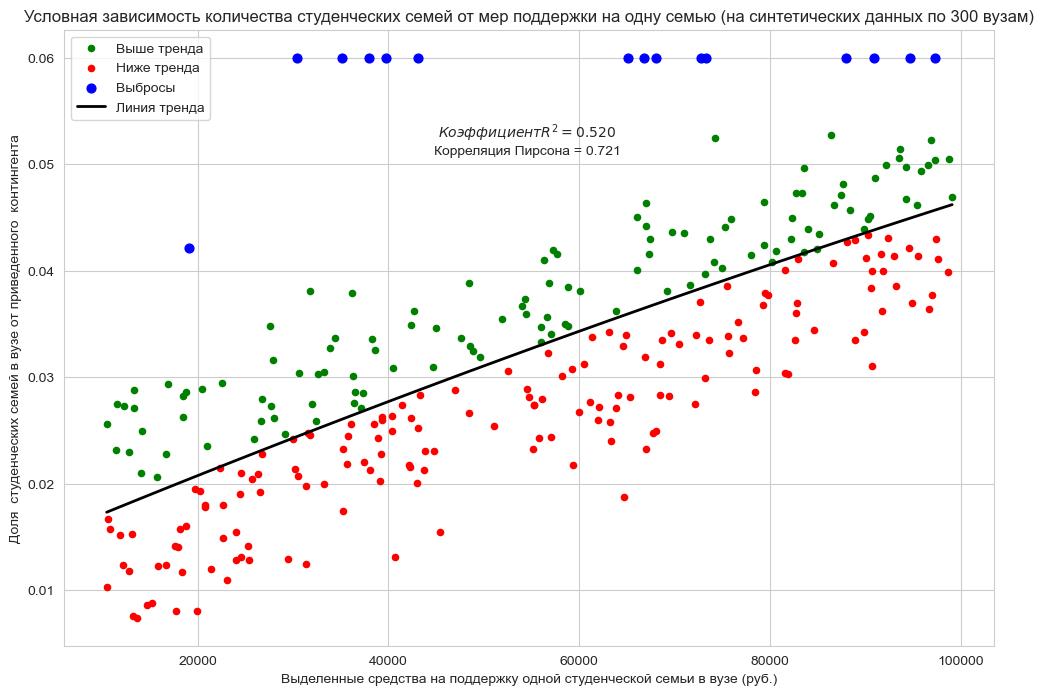

In [4]:
# Настройка фигуры и осей
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Отображение точек выше и ниже трендовой линии разными цветами
plt.scatter(x[above_trend & normal_points_idx], y[above_trend & normal_points_idx], color='green', s=20, label='Выше тренда')
plt.scatter(x[below_trend & normal_points_idx], y[below_trend & normal_points_idx], color='red', s=20, label='Ниже тренда')

# Обозначение выбросов более крупными точками
plt.scatter(x[outliers_idx], y[outliers_idx], color='blue', s=40, label='Выбросы')

# Добавление трендовой линии
plt.plot(trend_x, trend_y, color='black', linewidth=2, label='Линия тренда')

# Добавление текста с коэффициентами на график
plt.text(
    x=x.mean(),
    y=y.max()*0.9,
    s=f'$Коэффициент R^2 = {r_squared:.3f}$\nКорреляция Пирсона = {corr_coef:.3f}',
    ha='center',
    va='top'
)

# Настройки графика
plt.xlabel('Выделенные средства на поддержку одной студенческой семьи в вузе (руб.)')
plt.ylabel('Доля  студенческих семей в вузе от приведенного  контингента')
plt.title('Условная зависимость количества студенческих семей от мер поддержки на одну семью (на синтетических данных по 300 вузам)')
plt.legend()
plt.savefig('график_студенческие семьи.png', dpi=300)

# Показ графика
plt.show()